<a href="https://colab.research.google.com/github/DigoShane/GitHub-ML/blob/main/Understanding_the_Kernel_Limit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In this code we are trying to understand the main point behind the Neural Tangent Kernel Limit.

The idea is to see what happens with a 1 layer NN, with different activations and as we increase the width

In [26]:
# ============================================================
# CELL 1: USER-ADJUSTABLE SETTINGS
# ============================================================

# -----------------------------
# Reproducibility
# -----------------------------
RANDOM_SEED = 42


# -----------------------------
# Neural-network architecture
# -----------------------------
NUMBER_OF_NEURONS = 200

# Activation is fixed to ReLU in this notebook.


# -----------------------------
# Training settings
# -----------------------------
NUMBER_OF_EPOCHS = 2000000
LEARNING_RATE = 1.0e-3

OPTIMIZER_NAME = "Adam"
# Options:
#   "Adam"
#   "SGD"

SGD_MOMENTUM = 0.0
WEIGHT_DECAY = 0.0

PRINT_EVERY = 1000


# -----------------------------
# Data settings
# -----------------------------
USE_CUSTOM_DATA = False

# Used only when USE_CUSTOM_DATA = False.
NUMBER_OF_DATA_POINTS = 100

X_MIN = 0.0
X_MAX = 1.0

ADD_NOISE = False
NOISE_STANDARD_DEVIATION = 0.05


# -----------------------------
# Plotting settings
# -----------------------------
NUMBER_OF_PLOT_POINTS = 2000

# Plot only the first PLOT_FIRST_PARAMETERS entries of
# w_i, b_i, and a_i.
PLOT_FIRST_PARAMETERS = 500

FIGURE_WIDTH = 11
FIGURE_HEIGHT = 5

MARKER_SIZE = 25


# -----------------------------
# Device and precision
# -----------------------------
USE_GPU = True

DTYPE_NAME = "float32"
# Options:
#   "float32"
#   "float64"


# -----------------------------
# Example target function
# Used only when USE_CUSTOM_DATA = False.
# Modify this function as needed.
# -----------------------------
def target_function(x):
    return (
        torch.sin(4.0 * torch.pi * x)
        + 0.3 * torch.sin(10.0 * torch.pi * x)
    )


# -----------------------------
# Custom data
# Used only when USE_CUSTOM_DATA = True.
#
# Replace the arrays below with your own data.
# x and y must have the same length.
# -----------------------------
CUSTOM_X_DATA = [
    0.00,
    0.10,
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80,
    0.90,
    1.00,
]

CUSTOM_Y_DATA = [
    0.00,
    0.55,
    0.90,
    0.75,
    0.20,
    -0.25,
    -0.80,
    -0.95,
    -0.60,
    -0.10,
    0.20,
]

In [27]:
# @title
# ============================================================
# CELL 2: IMPORTS AND DEVICE
# ============================================================

import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Random seed
# ------------------------------------------------------------

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)


# ------------------------------------------------------------
# Data type
# ------------------------------------------------------------

if DTYPE_NAME.lower() == "float32":
    DTYPE = torch.float32

elif DTYPE_NAME.lower() == "float64":
    DTYPE = torch.float64

else:
    raise ValueError(
        "DTYPE_NAME must be either 'float32' or 'float64'."
    )


# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

if USE_GPU and torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")


print("Device:", DEVICE)
print("Data type:", DTYPE)

Device: cuda
Data type: torch.float32


Number of data points: 100
x range: 0.0 to 1.0


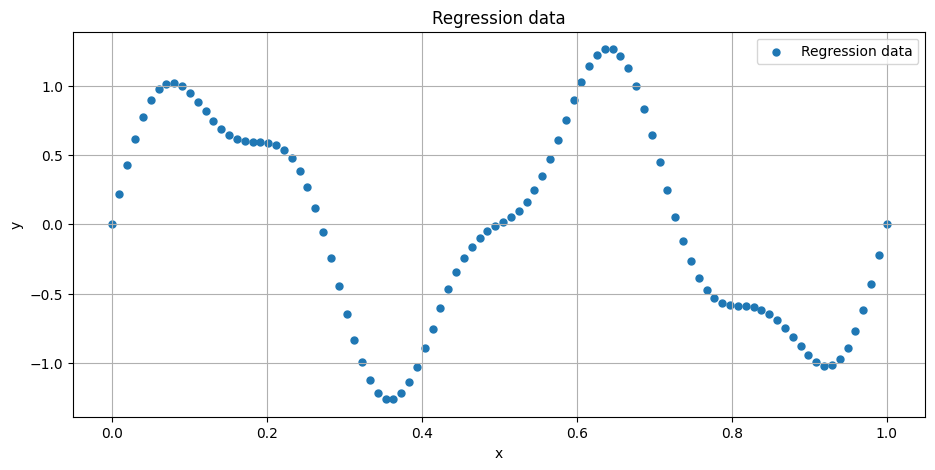

In [28]:
# @title
# ============================================================
# CELL 3: CREATE OR LOAD DATA
# ============================================================

if USE_CUSTOM_DATA:

    x_data_numpy = np.asarray(
        CUSTOM_X_DATA,
        dtype=np.float64
    ).reshape(-1, 1)

    y_data_numpy = np.asarray(
        CUSTOM_Y_DATA,
        dtype=np.float64
    ).reshape(-1, 1)

    if len(x_data_numpy) != len(y_data_numpy):
        raise ValueError(
            "CUSTOM_X_DATA and CUSTOM_Y_DATA must have "
            "the same number of entries."
        )

    x_data = torch.tensor(
        x_data_numpy,
        dtype=DTYPE,
        device=DEVICE
    )

    y_data = torch.tensor(
        y_data_numpy,
        dtype=DTYPE,
        device=DEVICE
    )

else:

    x_data = torch.linspace(
        X_MIN,
        X_MAX,
        NUMBER_OF_DATA_POINTS,
        dtype=DTYPE,
        device=DEVICE
    ).reshape(-1, 1)

    y_data = target_function(x_data)

    if ADD_NOISE:
        y_data = (
            y_data
            + NOISE_STANDARD_DEVIATION
            * torch.randn_like(y_data)
        )


# Sort data by x-coordinate
sorting_indices = torch.argsort(
    x_data[:, 0]
)

x_data = x_data[sorting_indices]
y_data = y_data[sorting_indices]


print("Number of data points:", len(x_data))
print("x range:", x_data.min().item(), "to", x_data.max().item())


plt.figure(
    figsize=(FIGURE_WIDTH, FIGURE_HEIGHT)
)

plt.scatter(
    x_data.detach().cpu().numpy(),
    y_data.detach().cpu().numpy(),
    s=MARKER_SIZE,
    label="Regression data"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Regression data")
plt.grid(True)
plt.legend()
plt.show()

In [29]:
# @title
# ============================================================
# CELL 4: ONE-HIDDEN-LAYER RELU NETWORK
# ============================================================

class OneHiddenLayerReLU(nn.Module):
    """
    One-dimensional, one-hidden-layer ReLU network:

        u(x) = sum_i a_i ReLU(w_i x + b_i) + c
    """

    def __init__(self, number_of_neurons):
        super().__init__()

        self.hidden_layer = nn.Linear(
            in_features=1,
            out_features=number_of_neurons,
            bias=True
        )

        self.output_layer = nn.Linear(
            in_features=number_of_neurons,
            out_features=1,
            bias=True
        )

        self.activation = nn.ReLU()

    def forward(self, x):

        hidden_preactivation = self.hidden_layer(x)
        hidden_activation = self.activation(hidden_preactivation)
        output = self.output_layer(hidden_activation)

        return output


model = OneHiddenLayerReLU(
    number_of_neurons=NUMBER_OF_NEURONS
).to(
    device=DEVICE,
    dtype=DTYPE
)


# ------------------------------------------------------------
# Save all initial parameters before training
# ------------------------------------------------------------

initial_w_values = (
    model.hidden_layer.weight
    .detach()
    .cpu()
    .numpy()
    .reshape(-1)
    .copy()
)

initial_b_values = (
    model.hidden_layer.bias
    .detach()
    .cpu()
    .numpy()
    .reshape(-1)
    .copy()
)

initial_a_values = (
    model.output_layer.weight
    .detach()
    .cpu()
    .numpy()
    .reshape(-1)
    .copy()
)

initial_c_value = (
    model.output_layer.bias
    .detach()
    .cpu()
    .item()
)


number_of_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)


print(model)
print("Number of hidden neurons:", NUMBER_OF_NEURONS)
print("Number of trainable parameters:", number_of_parameters)
print("Expected number of parameters:", 3 * NUMBER_OF_NEURONS + 1)

print("\nInitial output bias c =", initial_c_value)

OneHiddenLayerReLU(
  (hidden_layer): Linear(in_features=1, out_features=200, bias=True)
  (output_layer): Linear(in_features=200, out_features=1, bias=True)
  (activation): ReLU()
)
Number of hidden neurons: 200
Number of trainable parameters: 601
Expected number of parameters: 601

Initial output bias c = -0.03811009228229523


In [30]:
# @title
# ============================================================
# CELL 5: LOSS FUNCTION AND OPTIMIZER
# ============================================================

# Mean squared error is the discrete L2 regression loss.
loss_function = nn.MSELoss()


if OPTIMIZER_NAME.lower() == "adam":

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )

elif OPTIMIZER_NAME.lower() == "sgd":

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=LEARNING_RATE,
        momentum=SGD_MOMENTUM,
        weight_decay=WEIGHT_DECAY
    )

else:

    raise ValueError(
        "OPTIMIZER_NAME must be either 'Adam' or 'SGD'."
    )


print("Optimizer:", optimizer)

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0
)


In [31]:
# @title
# ============================================================
# CELL 6: TRAINING LOOP
# ============================================================

epoch_history = []
loss_history = []


model.train()

for epoch in range(NUMBER_OF_EPOCHS + 1):

    optimizer.zero_grad(set_to_none=True)

    prediction = model(x_data)

    loss = loss_function(
        prediction,
        y_data
    )

    loss.backward()

    optimizer.step()


    epoch_history.append(epoch)
    loss_history.append(loss.item())


    if (
        epoch % PRINT_EVERY == 0
        or epoch == NUMBER_OF_EPOCHS
    ):

        print(
            f"Epoch {epoch:7d} | "
            f"L2/MSE loss = {loss.item():.8e}"
        )

Epoch       0 | L2/MSE loss = 6.16333544e-01
Epoch    1000 | L2/MSE loss = 6.84277788e-02
Epoch    2000 | L2/MSE loss = 2.05602124e-02
Epoch    3000 | L2/MSE loss = 1.70705561e-02
Epoch    4000 | L2/MSE loss = 1.57899596e-02
Epoch    5000 | L2/MSE loss = 1.45590948e-02
Epoch    6000 | L2/MSE loss = 1.33085633e-02
Epoch    7000 | L2/MSE loss = 1.21245934e-02
Epoch    8000 | L2/MSE loss = 1.10635934e-02
Epoch    9000 | L2/MSE loss = 1.00859161e-02
Epoch   10000 | L2/MSE loss = 5.02860220e-03
Epoch   11000 | L2/MSE loss = 4.17945255e-03
Epoch   12000 | L2/MSE loss = 4.03606705e-03
Epoch   13000 | L2/MSE loss = 3.78354359e-03
Epoch   14000 | L2/MSE loss = 3.76624824e-03
Epoch   15000 | L2/MSE loss = 3.76632134e-03
Epoch   16000 | L2/MSE loss = 3.76500608e-03
Epoch   17000 | L2/MSE loss = 3.79155832e-03
Epoch   18000 | L2/MSE loss = 3.76503100e-03
Epoch   19000 | L2/MSE loss = 3.76494648e-03
Epoch   20000 | L2/MSE loss = 3.76677327e-03
Epoch   21000 | L2/MSE loss = 3.76504939e-03
Epoch   22

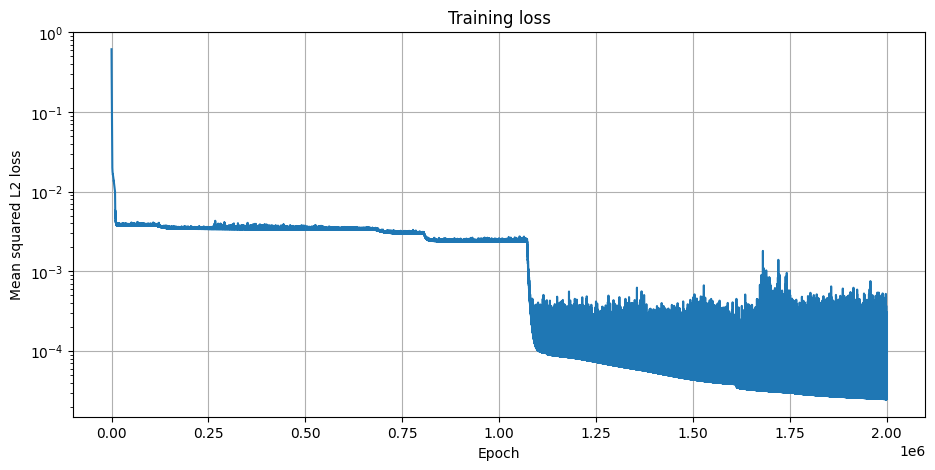

In [32]:
# @title
# ============================================================
# CELL 7: LOSS HISTORY
# ============================================================

plt.figure(
    figsize=(FIGURE_WIDTH, FIGURE_HEIGHT)
)

plt.semilogy(
    epoch_history,
    loss_history
)

plt.xlabel("Epoch")
plt.ylabel("Mean squared L2 loss")
plt.title("Training loss")
plt.grid(True)
plt.show()

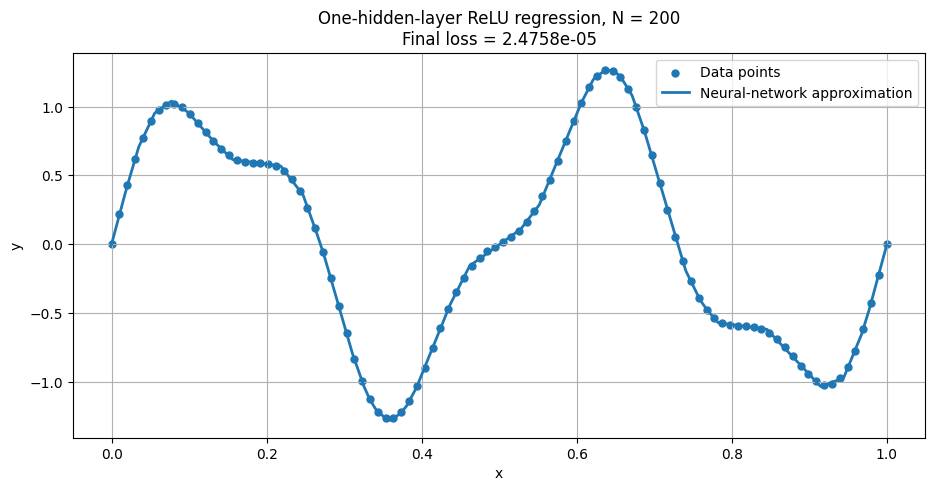

In [33]:
# @title
# ============================================================
# CELL 8: REGRESSION APPROXIMATION
# ============================================================

x_plot_min = x_data.min().item()
x_plot_max = x_data.max().item()

x_plot = torch.linspace(
    x_plot_min,
    x_plot_max,
    NUMBER_OF_PLOT_POINTS,
    dtype=DTYPE,
    device=DEVICE
).reshape(-1, 1)


model.eval()

with torch.no_grad():

    y_plot = model(x_plot)

    y_data_prediction = model(x_data)

    final_loss = loss_function(
        y_data_prediction,
        y_data
    ).item()


plt.figure(
    figsize=(FIGURE_WIDTH, FIGURE_HEIGHT)
)

plt.scatter(
    x_data.detach().cpu().numpy(),
    y_data.detach().cpu().numpy(),
    s=MARKER_SIZE,
    label="Data points"
)

plt.plot(
    x_plot.detach().cpu().numpy(),
    y_plot.detach().cpu().numpy(),
    linewidth=2,
    label="Neural-network approximation"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title(
    f"One-hidden-layer ReLU regression, "
    f"N = {NUMBER_OF_NEURONS}\n"
    f"Final loss = {final_loss:.4e}"
)

plt.grid(True)
plt.legend()
plt.show()

In [34]:
# @title
# ============================================================
# CELL 9: EXTRACT INITIAL AND FINAL TRAINED PARAMETERS
# ============================================================

# ------------------------------------------------------------
# Final hidden-layer weights w_i
# ------------------------------------------------------------

final_w_values = (
    model.hidden_layer.weight
    .detach()
    .cpu()
    .numpy()
    .reshape(-1)
    .copy()
)


# ------------------------------------------------------------
# Final hidden-layer biases b_i
# ------------------------------------------------------------

final_b_values = (
    model.hidden_layer.bias
    .detach()
    .cpu()
    .numpy()
    .reshape(-1)
    .copy()
)


# ------------------------------------------------------------
# Final output-layer weights a_i
# ------------------------------------------------------------

final_a_values = (
    model.output_layer.weight
    .detach()
    .cpu()
    .numpy()
    .reshape(-1)
    .copy()
)


# ------------------------------------------------------------
# Final scalar output bias c
# ------------------------------------------------------------

final_c_value = (
    model.output_layer.bias
    .detach()
    .cpu()
    .item()
)


number_to_plot = min(
    PLOT_FIRST_PARAMETERS,
    NUMBER_OF_NEURONS
)

parameter_indices = np.arange(
    1,
    number_to_plot + 1
)


print("Number of parameter entries plotted:", number_to_plot)

print("\nInitial output bias c =", initial_c_value)
print("Final output bias c   =", final_c_value)

print(
    "Absolute change in c  =",
    abs(final_c_value - initial_c_value)
)

Number of parameter entries plotted: 200

Initial output bias c = -0.03811009228229523
Final output bias c   = -0.2781439423561096
Absolute change in c  = 0.2400338500738144


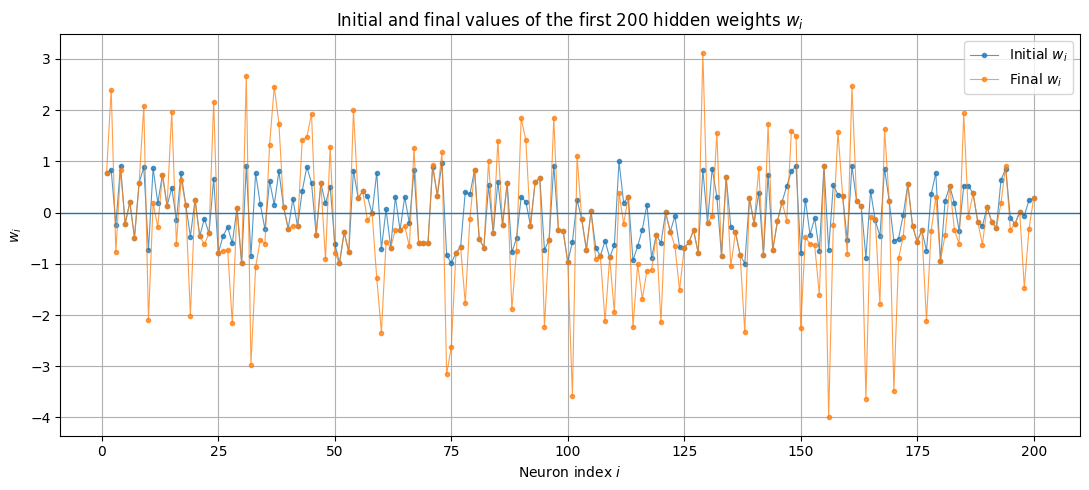

In [35]:
# @title
# ============================================================
# CELL 10: INITIAL AND FINAL w_i
# ============================================================

plt.figure(
    figsize=(FIGURE_WIDTH, FIGURE_HEIGHT)
)

plt.plot(
    parameter_indices,
    initial_w_values[:number_to_plot],
    marker="o",
    markersize=3,
    linewidth=0.8,
    alpha=0.75,
    label="Initial $w_i$"
)

plt.plot(
    parameter_indices,
    final_w_values[:number_to_plot],
    marker="o",
    markersize=3,
    linewidth=0.8,
    alpha=0.75,
    label="Final $w_i$"
)

plt.axhline(
    0.0,
    linewidth=1
)

plt.xlabel("Neuron index $i$")
plt.ylabel(r"$w_i$")

plt.title(
    f"Initial and final values of the first "
    f"{number_to_plot} hidden weights $w_i$"
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

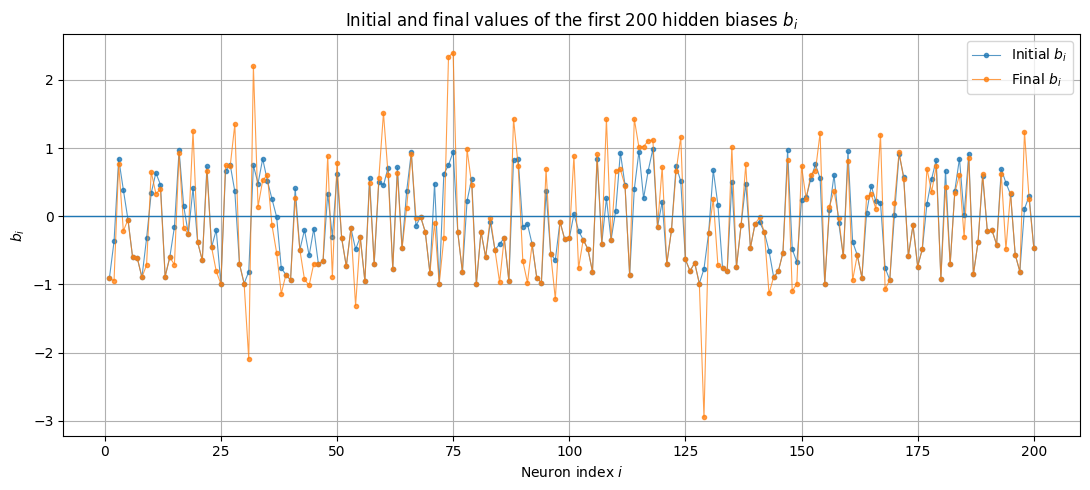

In [36]:
# @title
# ============================================================
# CELL 11: INITIAL AND FINAL b_i
# ============================================================

plt.figure(
    figsize=(FIGURE_WIDTH, FIGURE_HEIGHT)
)

plt.plot(
    parameter_indices,
    initial_b_values[:number_to_plot],
    marker="o",
    markersize=3,
    linewidth=0.8,
    alpha=0.75,
    label="Initial $b_i$"
)

plt.plot(
    parameter_indices,
    final_b_values[:number_to_plot],
    marker="o",
    markersize=3,
    linewidth=0.8,
    alpha=0.75,
    label="Final $b_i$"
)

plt.axhline(
    0.0,
    linewidth=1
)

plt.xlabel("Neuron index $i$")
plt.ylabel(r"$b_i$")

plt.title(
    f"Initial and final values of the first "
    f"{number_to_plot} hidden biases $b_i$"
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

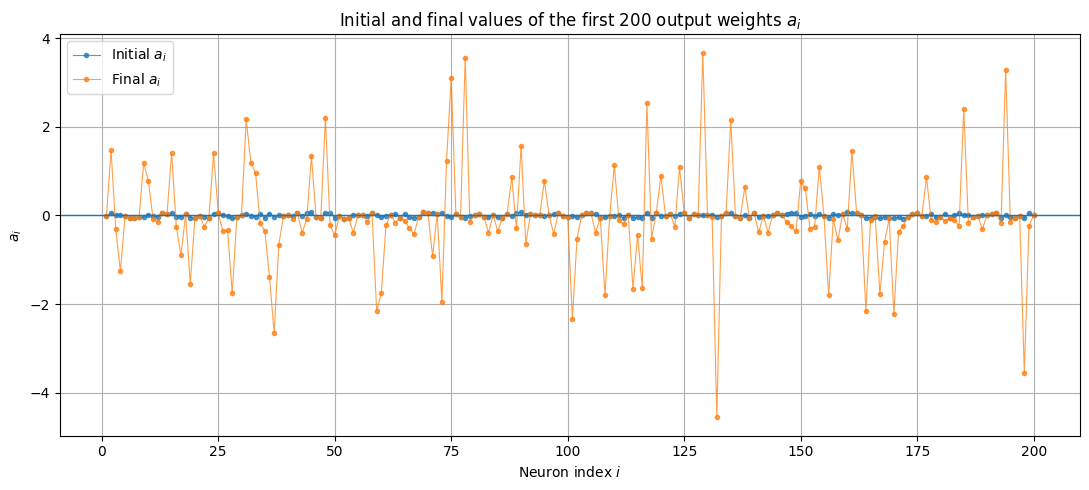

In [37]:
# @title
# ============================================================
# CELL 12: INITIAL AND FINAL a_i
# ============================================================

plt.figure(
    figsize=(FIGURE_WIDTH, FIGURE_HEIGHT)
)

plt.plot(
    parameter_indices,
    initial_a_values[:number_to_plot],
    marker="o",
    markersize=3,
    linewidth=0.8,
    alpha=0.75,
    label="Initial $a_i$"
)

plt.plot(
    parameter_indices,
    final_a_values[:number_to_plot],
    marker="o",
    markersize=3,
    linewidth=0.8,
    alpha=0.75,
    label="Final $a_i$"
)

plt.axhline(
    0.0,
    linewidth=1
)

plt.xlabel("Neuron index $i$")
plt.ylabel(r"$a_i$")

plt.title(
    f"Initial and final values of the first "
    f"{number_to_plot} output weights $a_i$"
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()